## 1. Importación de Librerías

In [32]:
from utils import *

## 2. Funciones Auxiliares

In [15]:
if CFG.colab:
    from google.colab import drive
    drive.mount('/content/drive')

## 3. Cargar Datos

In [16]:
# from google.colab import drive
# drive.mount('/content/drive')

In [17]:
def clean_feature_names(feature_names):
    """Remove characters that XGBoost doesn't allow in feature names."""
    cleaned = []
    for name in feature_names:
        # Replace brackets with parentheses or underscores
        cleaned_name = name.replace('[', ' (').replace(']', ')').replace('<', '_lt_')
        cleaned.append(cleaned_name)
    return cleaned

In [18]:
# Cargar datos imputados
df_imputed = pd.read_csv(CFG.path_df_imputed_corrected)
print(f"Dataset shape: {df_imputed.shape}")
df_imputed.columns = clean_feature_names(df_imputed.columns)
print(f"\nColumns: {list(df_imputed.columns)}")
df_imputed.tail()

Dataset shape: (2292, 33)

Columns: ['Plant_Height (cm)', 'Chlorophyll (SPAD)', 'Number of Flowers', 'Number of Harvested Fruits', 'Weight of Harvested Fruits (Kg)', 'Fruit Height (mm)', 'Sap pH', 'Sap K (ppm)', 'Sap Ca (ppm)', 'Sap Na (ppm)', 'Sap NO3 (ppm)', 'Sap Conductivity (mS/cm)', 'Soil pH Horiba', 'Soil K Horiba (ppm)', 'Soil Ca Horiba (ppm)', 'Soil Na Horiba (ppm)', 'Soil NO3 Horiba (ppm)', 'Soil Conductivity Horiba (mS/cm)', 'Fruit Diameter (mm)', '7in1_Ph (pH)', '7in1_Moisture (%RH)', '7in1_S_Temperature (C)', 'Air_sensor_Temperature (C)', 'Air_sensor_Humidity (%RH)', '7in1_Conductivity (mS/cm)', 'Pynamometer_Radiation (W/m2)', 'Nitrogen', 'Phosphorus', 'Potassium', 'Year', 'Month', 'Day', 'Treatment_Num']


,Plant_Height (cm),Chlorophyll (SPAD),Number of Flowers,Number of Harvested Fruits,Weight of Harvested Fruits (Kg),Fruit Height (mm),Sap pH,Sap K (ppm),Sap Ca (ppm),Sap Na (ppm),...,Air_sensor_Humidity (%RH),7in1_Conductivity (mS/cm),Pynamometer_Radiation (W/m2),Nitrogen,Phosphorus,Potassium,Year,Month,Day,Treatment_Num
2287,171.0,57.33,23.6,1.0,0.180,70.3,5.438,3580.0,385.4,49.60,...,79.64,0.1307,271.1,2.0,2.0,2.0,2024.0,12.0,4.0,27.0
2288,167.2,57.19,23.4,7.0,0.706,60.7,5.438,3230.0,263.2,49.70,...,68.08,0.1242,262.7,2.0,2.0,2.0,2024.0,12.0,4.0,27.0
2289,136.6,60.03,14.1,6.0,0.829,70.2,5.506,3490.0,226.0,57.10,...,63.30,0.0280,269.0,0.0,0.0,1.0,2024.0,12.0,4.0,4.0
2290,64.6,50.57,7.7,2.0,0.174,50.7,5.667,3330.0,223.6,50.35,...,53.07,0.2098,347.2,0.0,0.0,1.0,2024.0,12.0,4.0,4.0
2291,180.5,59.77,19.7,1.0,0.150,70.1,5.594,3480.0,181.2,57.40,...,64.70,0.0144,263.5,0.0,0.0,1.0,2024.0,12.0,4.0,4.0


In [19]:
list(MODELS_CONFIG.keys())

['RF', 'SVM', 'KNN', 'MLP', 'XGB']

## **5. Entrenamiento de Modelos**

## 5.0 Entrenar con variables MÁS importantes

In [20]:
CFG.class_path = f'{CFG.Root}/Resultados/classification_w_best_vars/'
os.makedirs(CFG.class_path, exist_ok=True)
CFG.path_pkl_results_classification = f"{CFG.class_path}class_results_individual_elements.pkl"

In [21]:
CFG.include_prod = False
CFG.individual_train = True
json_best_variables = Rf"{CFG.Root}\Resultados\classification_exclude_prod\most_frequent_variables_80.json"
list_best_vars = read_best_variables(json_best_variables)

In [22]:
list_best_vars

['Sap Na (ppm)',
 'Soil NO3 Horiba (ppm)',
 'Sap Conductivity (mS/cm)',
 'Soil pH Horiba',
 'Sap Ca (ppm)',
 'Chlorophyll (SPAD)',
 'Sap NO3 (ppm)',
 '7in1_S_Temperature(C)',
 'Soil Ca Horiba (ppm)',
 'Air_sensor_Humidity(%RH)',
 'Sap pH',
 '7in1_Ph(pH)',
 'Pynamometer_Radiation(W/m2)']

### 5.1 Train 3 Modelos (N,P,K) Individual

Se entrena para diferenciar la cantidad de fertilizante en cada elemento, un modelo por aparte

Deficiencia, adecuado, exceso

Categorías Modelo Nitrógeno: N0,N1,N2

Categorías Modelo Fósforo: P0,P1,P2

Categorías Modelo Potacio: K0,K1,K2

In [26]:
from joblib import Parallel, delayed

# Función wrapper para entrenar un modelo con un elemento específico
def entrenar_modelo_por_elemento(models_config, df_imputed, element, best_vars):
    """Entrena un modelo para un elemento específico."""
    dir_path = f"{CFG.class_path}{element}/"
    # asegurar que exista la ruta de resultados
    os.makedirs(dir_path, exist_ok=True)  # exist_ok=True evita el error si ya existe

    # NOTE: It can be changed by 'train_test_model'
    resultado = train_test_model_all_predictions(
        df_imputed=df_imputed,
        n_clases=None,  # No utilizar para este experimento
        models_config=models_config,
        element=element,
        usar_smote=False,
        mostrar_graficos=True,
        calcular_shap=True,
        dir_path=dir_path,
        best_variables=best_vars

    )
    return (element, resultado)

# Ejecutar todos los modelos y elementos en paralelo
if CFG.individual_train:
    all_results_list = Parallel(n_jobs=-1, verbose=10)(
        delayed(entrenar_modelo_por_elemento)(
            models_config=MODELS_CONFIG,
            df_imputed=df_imputed,
            element=element,
            best_vars = list_best_vars #acá se podría pasar solamente mejores variables segun el elemento, solo es una idea.
        ) for element in CFG.elements_list
    )

    # Organizar resultados en estructura de diccionario
    all_results = {}
    for element, resultado in all_results_list:
        if element not in all_results:
            all_results[element] = []
        all_results[element].append(resultado)

    print(f"Total de combinaciones: {len(all_results_list)}")


    path_classification_results = CFG.path_pkl_results_classification
    with open(path_classification_results, 'wb') as pkl_file:
        pickle.dump(all_results, pkl_file)

#========================================================
extract_top_x_percent_features(all_results, percent=0.8, class_path=CFG.class_path)
extract_top_x_percent_features(all_results, percent=0.7, class_path=CFG.class_path)

#========================================================

dict_class_algrtm_shap = category_algorithm_shap_values(all_results)
save_shap_category_algorithm_csv(dict_class_algrtm_shap, all_results, CFG.class_path)

ranking_vars_class = variable_importance_category_algorithm_shap(dict_class_algrtm_shap,
                                                                 percentage=0.8, 
                                                                 results_models_all=all_results, 
                                                                 dir_path=CFG.class_path)
save_top_variable_by_category(ranking_vars_class,
                            percentage=0.8,
                            dir_path=CFG.class_path)

ranking_vars_class = variable_importance_category_algorithm_shap(dict_class_algrtm_shap,
                                                                 percentage=0.7, 
                                                                 results_models_all=all_results, 
                                                                 dir_path=CFG.class_path)
save_top_variable_by_category(ranking_vars_class,
                            percentage=0.7,
                            dir_path=CFG.class_path)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


KeyboardInterrupt: 

### 5.2 Train Cuartiles (2 Categorías)

Se entrena para diferenciar los fertilizantes de los tratamientos Q1 vs Q4

In [ ]:
from joblib import Parallel, delayed

CFG.class_path = f'{CFG.Root}/Resultados/classification_cuartiles_all_models/'
os.makedirs(CFG.class_path, exist_ok=True)
CFG.individual_train = False
CFG.cuartiles_train = True

CFG.path_pkl_results_classification = f"{CFG.class_path}class_models_cuartiles_all_models.pkl"
# Función wrapper para entrenar un modelo con un elemento específico
# Función wrapper para entrenar un modelo con un elemento específico
def entrenar_modelo_por_elemento(models_config, df_imputed, element, best_vars):
    """Entrena un modelo para un elemento específico."""
    dir_path = f"{CFG.class_path}{element}/"
    # asegurar que exista la ruta de resultados
    os.makedirs(dir_path, exist_ok=True)  # exist_ok=True evita el error si ya existe

    # NOTE: It can be changed by 'train_test_model'
    resultado = train_test_model_all_predictions(
        df_imputed=df_imputed,
        n_clases=None,  # No utilizar para este experimento
        models_config=models_config,
        element=element,
        usar_smote=False,
        mostrar_graficos=True,
        calcular_shap=True,
        dir_path=dir_path,
        best_variables=best_vars

    )
    return resultado

if CFG.cuartiles_train:
    resultado = entrenar_modelo_por_elemento(models_config=MODELS_CONFIG,
            df_imputed=df_imputed,
            element=None,
            best_vars = list_best_vars #acá se podría pasar solamente mejores variables segun el elemento, solo es una idea.
        )
    # Organizar resultados en estructura de diccionario
    all_results = {"All_models": resultado}

    print(f"Total de combinaciones: {len(all_results_list)}")


    path_classification_results = CFG.path_pkl_results_classification
    with open(path_classification_results, 'wb') as pkl_file:
        pickle.dump(all_results, pkl_file)

#========================================================
extract_top_x_percent_features(all_results, percent=0.8, class_path=CFG.class_path)
extract_top_x_percent_features(all_results, percent=0.7, class_path=CFG.class_path)

## 6. Comparación de Resultados

In [ ]:
with open(CFG.path_pkl_results_classification, 'rb') as pkl_file:
    todos_los_resultados = pickle.load(pkl_file)


NameError: name 'CFG' is not defined

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Estudio\\OneDrive - Universidad de Antioquia\\Estudio\\PAI\\Codigo\\Resultados\\classification_w_best_vars\\comparison_accuracy_test.png'

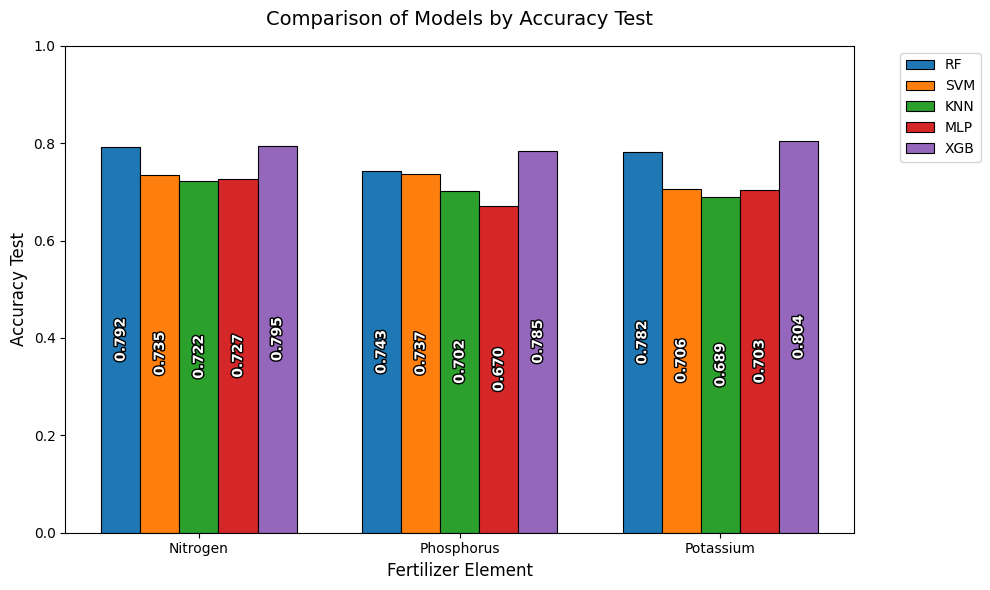

In [ ]:
# Consolidar todos los resultados
# todos_los_resultados = {
#     'Random Forest': resultados_rf,
#     'SVM': resultados_svm,
#     'KNN': resultados_knn,
#     'MLP': resultados_mlp
# }


# Comparar modelos
compare_classification_models(todos_los_resultados)

## 7. Visualizar y Exportar Resultados

In [103]:
# load pickle
with open(CFG.path_pkl_results_classification, 'rb') as pkl_file:
    todos_los_resultados = pickle.load(pkl_file)


### 7.1 Reporte Resultados por Clase

In [104]:
# Replace your current cell with:
for model_name, resultados in todos_los_resultados.items():
    print(f"\n{'='*80}")
    print(f"MODEL: {model_name}")
    print(f"{'='*80}")
    for i, resultado in enumerate(resultados):
        print(f"\n--- Configuration {i+1}: {resultado['n_clases']} ---")
        
        # Convert dict to DataFrame for nice display
        df_report = pd.DataFrame(resultado['classification_report']).transpose()
        display(df_report.round(2))
        
        # OR use the custom formatter
        # print(format_classification_report(resultado['classification_report']))


MODEL: RF

--- Configuration 1: 3_Nitrogen ---


,precision,recall,f1-score,support
0.0,0.82,0.76,0.79,228.00
1.0,0.80,0.76,0.78,229.00
2.0,0.77,0.85,0.81,231.00
accuracy,0.79,0.79,0.79,0.79
macro avg,0.79,0.79,0.79,688.00
weighted avg,0.79,0.79,0.79,688.00



--- Configuration 2: 3_Phosphorus ---


,precision,recall,f1-score,support
0.0,0.77,0.83,0.80,228.00
1.0,0.76,0.74,0.75,231.00
2.0,0.77,0.72,0.75,229.00
accuracy,0.77,0.77,0.77,0.77
macro avg,0.77,0.77,0.77,688.00
weighted avg,0.77,0.77,0.77,688.00



--- Configuration 3: 3_Potassium ---


...

,precision,recall,f1-score,support
0.0,0.82,0.75,0.78,228.0
1.0,0.81,0.79,0.80,229.0
2.0,0.77,0.85,0.81,231.0
accuracy,0.80,0.80,0.80,0.8
macro avg,0.80,0.80,0.80,688.0
weighted avg,0.80,0.80,0.80,688.0



--- Configuration 2: 3_Phosphorus ---


,precision,recall,f1-score,support
0.0,0.82,0.86,0.84,228.00
1.0,0.78,0.77,0.78,231.00
2.0,0.83,0.79,0.81,229.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.81,0.81,0.81,688.00
weighted avg,0.81,0.81,0.81,688.00



--- Configuration 3: 3_Potassium ---


,precision,recall,f1-score,support
0.0,0.84,0.82,0.83,229.0
1.0,0.78,0.78,0.78,230.0
2.0,0.80,0.80,0.80,229.0
accuracy,0.80,0.80,0.80,0.8
macro avg,0.80,0.80,0.80,688.0
weighted avg,0.80,0.80,0.80,688.0


### 7.2 Almacenar Resultados en general

In [105]:
# Crear DataFrame consolidado con todos los resultados
resultados_completos = []

for model_name, resultados in todos_los_resultados.items():
    for resultado in resultados:
        resultados_completos.append({
            'Model': model_name,
            'N_Classes': resultado['n_clases'],
            'Accuracy_Train': resultado['accuracy_train'],
            'Accuracy_Test': resultado['accuracy_test'],
            'F1_Train': resultado['f1_train'],
            'F1_Test': resultado['f1_test'],
            'Best_Params': str(resultado['best_params'])
        })

df_resultados = pd.DataFrame(resultados_completos)

# Guardar resultados
df_resultados.to_csv(f'{CFG.class_path}resultados_modelos_completos.csv', index=False)
print(f"\nResults saved to: {CFG.class_path}resultados_modelos_completos.csv")

# Mostrar tabla
print("\n" + "="*100)
print("COMPLETE RESULTS TABLE")
print("="*100)
display(df_resultados.sort_values(['Model', 'N_Classes']))


Results saved to: ../Resultados/classification_include_prod/resultados_modelos_completos.csv

COMPLETE RESULTS TABLE


,Model,N_Classes,Accuracy_Train,Accuracy_Test,F1_Train,F1_Test,Best_Params
6,KNN,3_Nitrogen,0.833697,0.718023,0.833697,0.718023,{'clf__n_neighbors': 3}
7,KNN,3_Phosphorus,0.834788,0.716570,0.834788,0.716570,{'clf__n_neighbors': 3}
8,KNN,3_Potassium,0.882480,0.690407,0.882480,0.690407,{'clf__n_neighbors': 2}
9,MLP,3_Nitrogen,1.000000,0.718023,1.000000,0.718023,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
10,MLP,3_Phosphorus,1.000000,0.738372,1.000000,0.738372,"{'clf__alpha': 1e-05, 'clf__hidden_layer_sizes..."
11,MLP,3_Potassium,1.000000,0.728198,1.000000,0.728198,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
0,RF,3_Nitrogen,1.000000,0.793605,1.000000,0.793605,"{'clf__max_depth': 30, 'clf__n_estimators': 300}"
1,RF,3_Phosphorus,1.000000,0.765988,1.000000,0.765988,"{'clf__max_depth': 20, 'clf__n_estimators': 100}"
2,RF,3_Potassium,1.000000,0.780523,1.000000,0.780523,"{'clf__max_depth': 20, 'clf__n_estimators': 200}"
3,SVM,3_Nitrogen,0.999377,0.750000,0.999377,0.750000,"{'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel..."


## 8. Análisis del Mejor Modelo

In [ ]:
# Encontrar el mejor modelo
best_idx = df_resultados['F1_Macro_Test'].idxmax()
best_model_info = df_resultados.iloc[best_idx]

print("\n" + "="*80)
print("BEST OVERALL MODEL")
print("="*80)
print(f"Model: {best_model_info['Model']}")
print(f"Number of Classes: {best_model_info['N_Classes']:.0f}")
print(f"Test Accuracy: {best_model_info['Accuracy_Test']:.4f}")
print(f"Test F1 Macro: {best_model_info['F1_Macro_Test']:.4f}")
print(f"Best Parameters: {best_model_info['Best_Params']}")
print("="*80)

## 9. SHAP Waterfall Plot (Ejemplo)

In [ ]:
# Ejemplo de cómo crear un waterfall plot para un modelo específico
# Usaremos Random Forest con 9 clases como ejemplo

# Obtener el resultado específico
resultado_ejemplo = resultados_rf[-1]  # Último elemento (9 clases)
n_clases_ejemplo = resultado_ejemplo['n_clases']

# Preparar datos
X_train, X_test, y_train, y_test, feature_names, _ = preparar_datos(df_imputed, n_clases_ejemplo)

# Obtener el modelo entrenado
grid = resultado_ejemplo['grid_search']
scaler = grid.best_estimator_.named_steps['scaler']
clf = grid.best_estimator_.named_steps['clf']

# Escalar datos
X_train_scaled = scaler.transform(X_train)

# Crear explainer
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_train_scaled)

# Seleccionar una muestra y clase para visualizar
sample_idx = 0
class_idx = 0

# Crear Explanation object para waterfall
if isinstance(shap_values.values, list):
    sv = shap_values.values[class_idx][sample_idx]
    base = explainer.expected_value[class_idx]
else:
    # Para formato 3D (n_samples, n_features, n_classes) o (n_classes, n_samples, n_features)
    if shap_values.values.ndim == 3:
        if shap_values.values.shape[0] == len(X_train_scaled):
            sv = shap_values.values[sample_idx, :, class_idx]
        else:
            sv = shap_values.values[class_idx, sample_idx, :]
        base = explainer.expected_value[class_idx]
    else:
        sv = shap_values.values[sample_idx]
        base = explainer.expected_value

# Crear Explanation para waterfall
explanation = shap.Explanation(
    values=sv,
    base_values=base,
    data=X_train.iloc[sample_idx].values,
    feature_names=feature_names
)

# Visualizar waterfall
print(f"\nWaterfall plot for sample {sample_idx}, class {class_idx}")
print(f"True label: {y_train.iloc[sample_idx]}")
shap.plots.waterfall(explanation)
plt.tight_layout()
plt.show()